In [180]:
from py_files.setup import *
setup_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. initial simulation

In [181]:
# _, tau_long1, _, _ = shocks.temp_tc()
# _, tau_long2, _, _ = shocks.perm_tc()
# _, tau_long3, _, _ = shocks.perm_tc_emp()

# print(np.round(tau_long1, decimals=4))
# print(np.round(tau_long2, decimals=4))
# print(tau_long3)

In [182]:
# 1. calibrate
m = CapIncModel()
out = m.calibrate(target_elas1=m.phi1, target_elas2=m.phi2,)

# 2. pin baseline SS first
T=25; tau0=0.0; tauT=-0.1; rho=0.85; tail=60; tau_ss=0.0 
ss0 = m.solve_steady_state(tau=tau0)


 Calibrate household: zero wage premia + target eps_nI 
targets    prem1=0, prem2=0, eps1=1.0, eps2=0.3
------------------------------------------------------------
old        mu1=0.26, mu2=0.25   =>
           log(w1I/w1C)=-2.25e-01, log(w2I/w2C)=-7.60e-01

old        phi1=1.00, phi2=0.30 =>
           eps1=0.781, eps2=0.237
------------------------------------------------------------
new        mu1=0.1832, mu2=0.1104   =>
           log(w1I/w1C)=-3.12e-12, log(w2I/w2C)=+3.04e-12

new        phi1=1.2242, phi2=0.3372 =>
           eps1=1.000, eps2=0.300



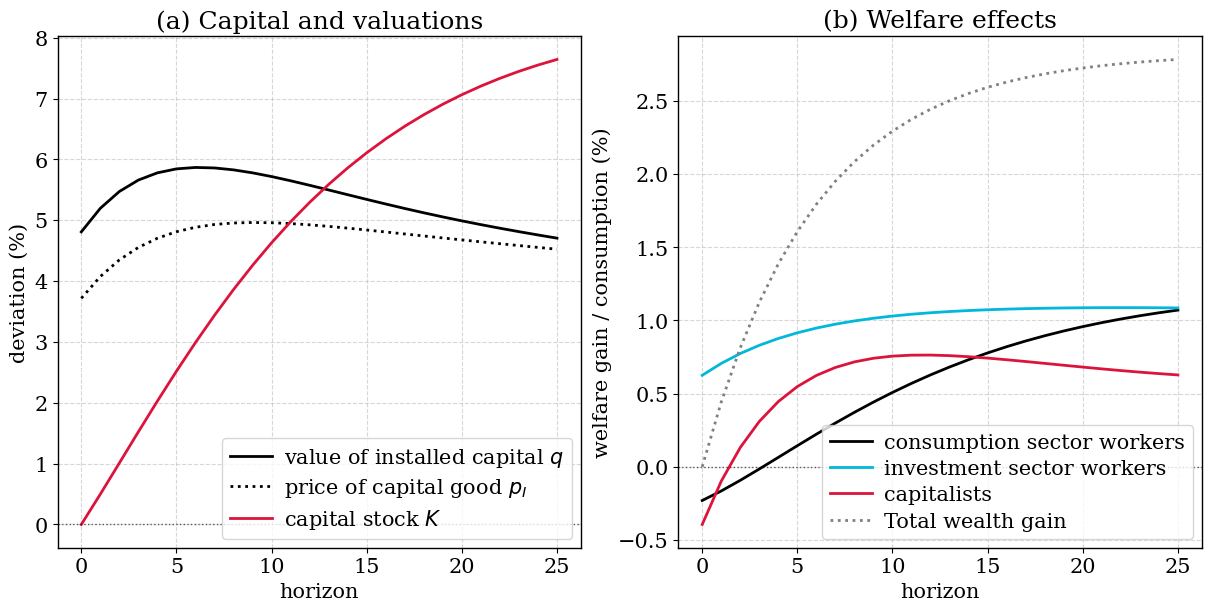

In [183]:
# 2. params and sim
net_long, tau_long, dlog_net_long, tauT = shocks.perm_tc(
    T=T, tau0=tau0, tauT=tauT, rho=rho, tail=tail,
)

sim_raw = m.solve_transition(tau_path=tau_long, tau_terminal=tauT)

fig, (ax1, ax2), ss, sim = build_output.welfare_effects(
    m, sim_raw, tau_long, dlog_net_long, T=T, tail=tail, tau_ss=tau_ss
)

In [184]:
res_elas = build_output.inc_elas(m, sim, tau=tau_ss)


--------------------------------------------
 Incidence (share of total welfare gain) 
--------------------------------------------
Consumption workers     25.6%
Investment workers      49.5%
Capitalists             24.9%

--------------------------------------------
 Elasticities 
--------------------------------------------
epsS_LR        1.18
epsS_SR        0.10
epsD           0.99

--------------------------------------------
 Tax elasticities (LR GE) 
--------------------------------------------
price_elas     0.61
quant_elas     0.72
wealth_ela     1.32



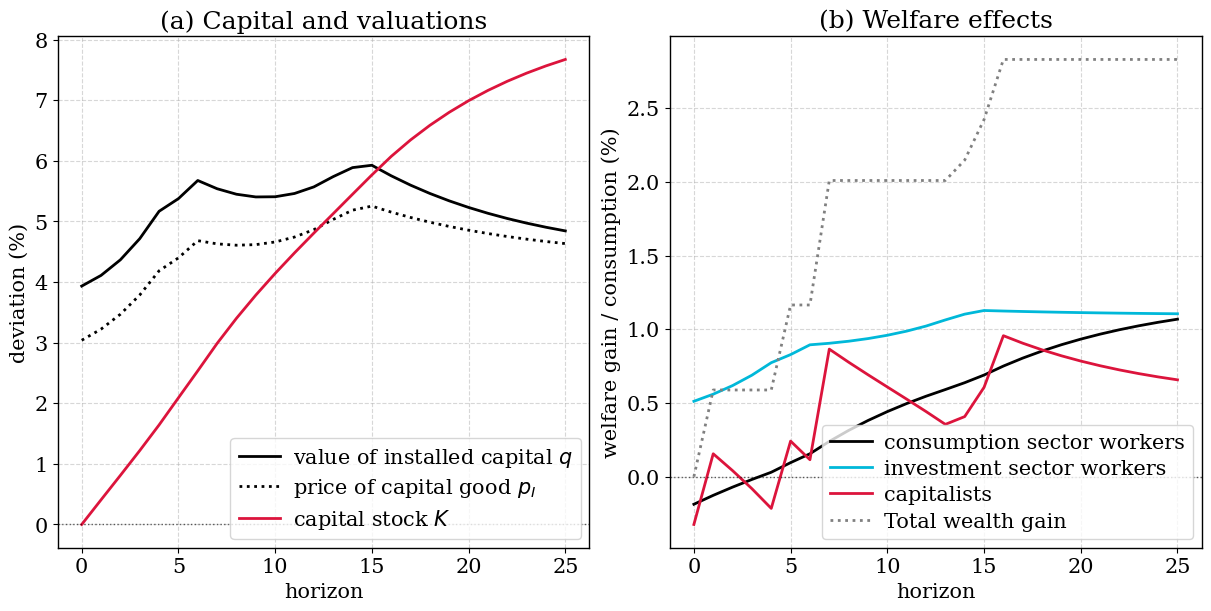

In [185]:
# 1. get empirical path
net_long, tau_long, dlog_net_long, tauT = shocks.perm_tc_emp(
    tail=tail, normalized=True
)

tau0 = tau_long[0]

# 2. pin baseline SS 
ss0 = m.solve_steady_state(tau=tau0)

# 3. simulate
sim_raw = m.solve_transition(tau_path=tau_long, tau_terminal=tauT)

# 4. plot
fig, (ax1, ax2), ss, sim = build_output.welfare_effects(
    m, sim_raw, tau_long, dlog_net_long, T=T, tail=tail, tau_ss=tau_ss
)

In [186]:
res_elas = build_output.inc_elas(m, sim, tau=tau_ss)


--------------------------------------------
 Incidence (share of total welfare gain) 
--------------------------------------------
Consumption workers     26.5%
Investment workers      51.3%
Capitalists             22.2%

--------------------------------------------
 Elasticities 
--------------------------------------------
epsS_LR        1.18
epsS_SR        0.10
epsD           0.99

--------------------------------------------
 Tax elasticities (LR GE) 
--------------------------------------------
price_elas     0.61
quant_elas     0.72
wealth_ela     1.32



### 2. labour dynamics

*and assess the labour share*

In [187]:
# 1. initiate
gamma  = 0.62
T_solve = T + tail

# anchor baseline SS at tau0
ss0 = m.solve_steady_state(tau=tau0)
ss1 = m.solve_steady_state(tau=tauT)

In [188]:
# 1.paths
_, tau_t1_long, _, _ = shocks.perm_tc(T=T, tail=tail, tau0=tau0, tauT=tauT, rho=rho)
tau_t2_long = np.full_like(tau_t1_long, tau0)
tau_t3_long = np.full_like(tau_t1_long, tauT)
_, tau_t4_long, _, _  = shocks.perm_tc_emp(tail=tail)

# 3. intial guesses
qg0 = np.full(T_solve + 1, ss0["q"])
qg1 = np.full(T_solve + 1, ss1["q"])

# 4. simulations
# 4.1 baseline ss
sim2 = m.solve_transition(tau_path=tau_t2_long, K0=ss0["K"],
                          q_guess_path=qg0, tau_terminal=tau0)
ls2_full = build_output.labour_share(m, sim2, gamma=gamma)

# 4.2 new ss
sim3 = m.solve_transition(tau_path=tau_t3_long, K0=ss1["K"],
                          q_guess_path=qg1, tau_terminal=tauT)
ls3_full = build_output.labour_share(m, sim3, gamma=gamma)

# 4.3 permanent shock
sim1 = m.solve_transition(tau_path=tau_t1_long, K0=ss0["K"],
                          q_guess_path=qg0, tau_terminal=tauT)
ls1_full = build_output.labour_share(m, sim1, gamma=gamma)

# 4.4 permanent shock (empirical)
sim4 = m.solve_transition(tau_path=tau_t4_long, K0=ss0["K"],
                          q_guess_path=qg0, tau_terminal=tauT)
ls4_full = build_output.labour_share(m, sim4, gamma=gamma)

/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_nonlin.py:374: RuntimeWarning: invalid value encountered in scalar divide
  and dx_norm/self.x_rtol <= x_norm))


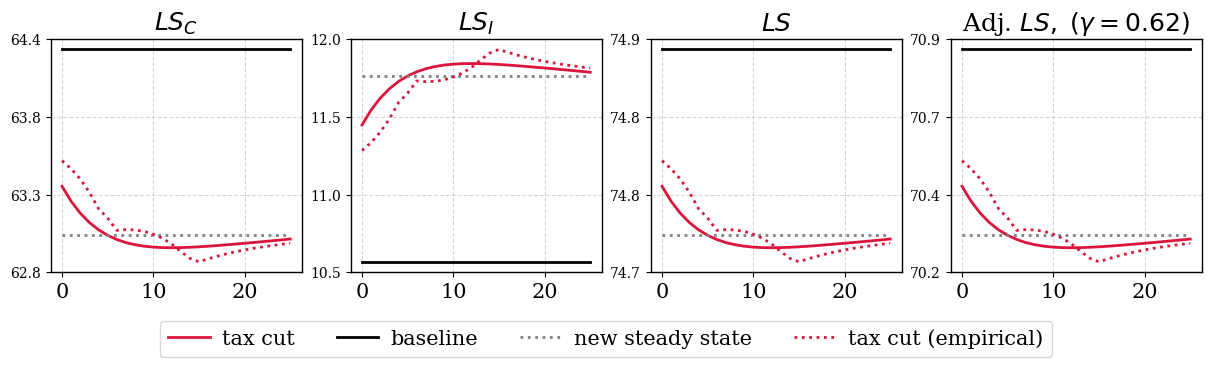

In [189]:
sl = slice(0, T + 1)
ls1 = {k: np.asarray(v)[sl] for k, v in ls1_full.items()}
ls2 = {k: np.asarray(v)[sl] for k, v in ls2_full.items()}
ls3 = {k: np.asarray(v)[sl] for k, v in ls3_full.items()}
ls4 = {k: np.asarray(v)[sl] for k, v in ls4_full.items()}
h = np.arange(T + 1)

ncols, nrows = 4, 1

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3), sharex=True, constrained_layout=True)
axes = axes.ravel()

panels = list(var_groups.panels(gamma))   
n_used = len(panels)

# plot used panels
for i, (k, ttl) in enumerate(panels):
    ax = axes[i]
    ax.plot(h, ls1[k] *100, lw=2, color="crimson")
    ax.plot(h, ls2[k] *100, lw=2, color="k")
    ax.plot(h, ls3[k] *100, lw=2, color="gray", ls=":")
    ax.plot(h, ls4[k] *100, lw=2, color="crimson", ls=":")
    ax.set_title(ttl)
    # ax.set_xlabel("horizon")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

    ax.yaxis.set_major_locator(mticker.LinearLocator(4))
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.tick_params(axis="y", labelsize=10)


handles = [
    plt.Line2D([0], [0], color="crimson", lw=2, ls="-"),
    plt.Line2D([0], [0], color="k",       lw=2, ls="-"),
    plt.Line2D([0], [0], color="gray",    lw=2, ls=":"),
    plt.Line2D([0], [0], color="crimson", lw=2, ls=":"),
]
labels = ["tax cut", "baseline", "new steady state", "tax cut (empirical)"]

fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.20),  # move up/down as needed
    ncol=len(labels),
    frameon=True
)

plt.show()

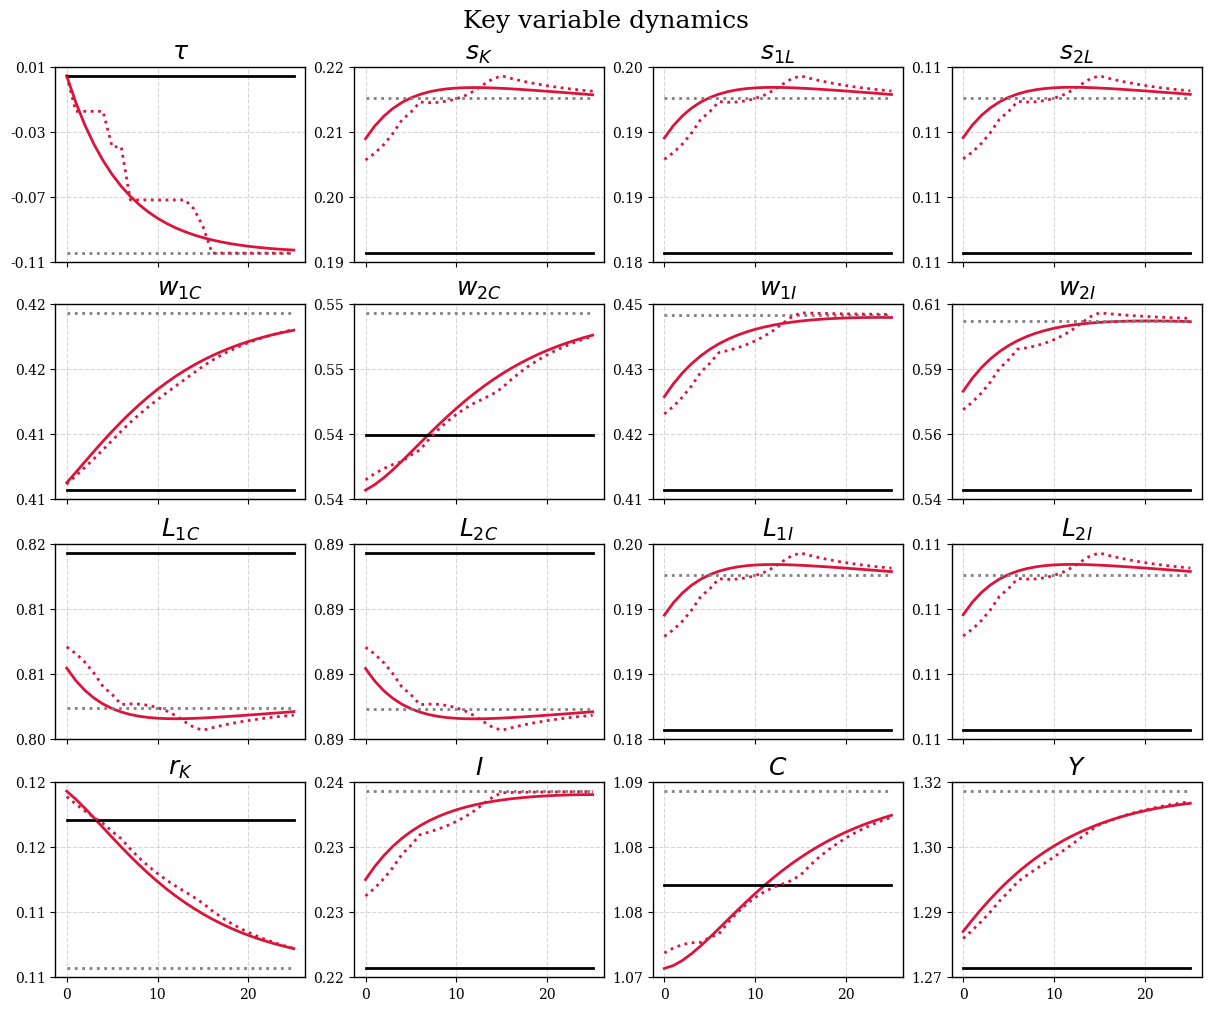

In [190]:
sl = slice(0, T + 1)

def trunc_pack(sim, ls):
    S = {**sim, **ls}
    out = {}
    for k, v in S.items():
        a = np.asarray(v)
        out[k] = a[sl] if a.ndim >= 1 and len(a) >= (T + 1) else v
    return out

S1 = trunc_pack(sim1, ls1)
S2 = trunc_pack(sim2, ls2)
S3 = trunc_pack(sim3, ls3)
S4 = trunc_pack(sim4, ls4)

keys = [
    "tau",
    # "pI","q","K",
    "sK","s1","s2",
    "w1C","w2C","w1I","w2I",
    "L1C","L2C","L1I","L2I",
    "rC_gross","I","C","Y"
]

# keep only keys that exist in all three
keys = [k for k in keys if (k in S1) and (k in S2) and (k in S3) and (k in S4)]

T = min(
    len(np.asarray(S1[keys[0]])), 
    len(np.asarray(S2[keys[0]])), 
    len(np.asarray(S3[keys[0]])), 
    len(np.asarray(S4[keys[0]]))
)
h = np.arange(T)

ncols = 4
nrows = math.ceil(len(keys) / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(12, 2.5*nrows),
    sharex=True,
    constrained_layout=True
)
axes = np.atleast_1d(axes).ravel()
fig.suptitle('Key variable dynamics')

for i, k in enumerate(keys):
    ax = axes[i]
    ax.plot(h, np.asarray(S1[k])[:T], lw=2, color="crimson")
    ax.plot(h, np.asarray(S2[k])[:T], lw=2, color="k")
    ax.plot(h, np.asarray(S3[k])[:T], lw=2, color="gray", ls=':')
    ax.plot(h, np.asarray(S4[k])[:T], lw=2, color="crimson", ls=':')
    ax.set_title(var_groups.model_var.get(k, k))
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

for ax in axes:
    ax.yaxis.set_major_locator(mticker.LinearLocator(4))
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=10)
    
    
# hide any unused panels
for j in range(len(keys), len(axes)):
    axes[j].set_axis_off()

# one legend for the whole figure
axes[0].plot([], [], lw=2, color="crimson", label="tax cut")
axes[0].plot([], [], lw=2, color="k",  label="baseline")
axes[0].plot([], [], lw=2, color="gray", ls=':',  label="new steady state")
axes[0].plot([], [], lw=2, color="crimson", ls=':',  label="tax cut (empirical)")

first_empty = len(keys)

# 2) turn all unused axes off
for j in range(first_empty, len(axes)):
    axes[j].set_axis_off()

# 3) use the first empty one to host the legend
if first_empty < len(axes):
    ax_leg = axes[first_empty]
    ax_leg.set_axis_off()

    # proxy handles (clean + independent of what's plotted)
    h1 = plt.Line2D([0], [0], color="crimson", lw=2)
    h2 = plt.Line2D([0], [0], color="k",  lw=2)
    h3 = plt.Line2D([0], [0], color="crimson", ls=':',  lw=2)
    h4 = plt.Line2D([0], [0], color="gray", ls=':',  lw=2)

    ax_leg.legend(
        [h1, h2, h3, h4], 
        ["tax cut", "baseline", 'new steady state', 'tax cut (empirical)'], 
        loc="center", frameon=True)

plt.show()